# **Day 8: Calculus and Automatic Differentiation**
*Module 1 - Foundations and Tools*

Training an ML model = **minimising a loss function**. To minimise we need to know which way is "downhill": that is the **derivative** (one parameter) or the **gradient** (many parameters). Neural networks compute millions of gradients with the **chain rule**, automated by **automatic differentiation**.

> Calculus tells us how a quantity changes when an input changes a little (the derivative or gradient). Training a model means following the gradient downhill to reduce the error. Automatic differentiation computes these gradients for us.
>
> *Example:* If increasing a weight by 0.01 reduces the error by 0.05, the gradient is about -5, so we should keep increasing that weight.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(8)

## **1. The Derivative**
$$f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$$
It is the slope of the tangent line: how much $f$ changes for a tiny change in $x$.

analytical f'(1.5) = 3.750000 | numerical = 3.750000


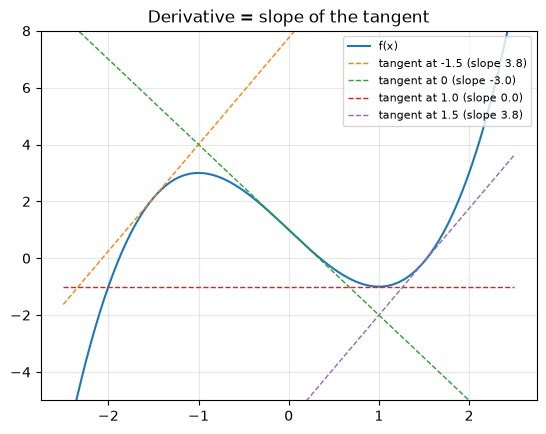

In [2]:
f = lambda x: x ** 3 - 3 * x + 1
df = lambda x: 3 * x ** 2 - 3                       # analytical derivative

def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)           # central difference: error O(h^2)

x0 = 1.5
print(f"analytical f'({x0}) = {df(x0):.6f} | numerical = {numerical_derivative(f, x0):.6f}")

xs = np.linspace(-2.5, 2.5, 200)
plt.plot(xs, f(xs), label="f(x)")
for p in [-1.5, 0, 1.0, 1.5]:
    plt.plot(xs, f(p) + df(p) * (xs - p), "--", lw=1, label=f"tangent at {p} (slope {df(p):.1f})")
plt.ylim(-5, 8); plt.legend(fontsize=8); plt.title("Derivative = slope of the tangent"); plt.grid(alpha=0.3); plt.show()

At $x=\pm1$ the slope is 0: these are a local maximum and a local minimum. Optimisation looks for points where the gradient is zero.

## **2. Partial Derivatives and the Gradient**
For $f(w_1, w_2)$, the **gradient** $\nabla f = \left[\frac{\partial f}{\partial w_1}, \frac{\partial f}{\partial w_2}\right]$ points in the direction of **steepest ascent**. Gradient descent steps in the opposite direction: $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla f$.

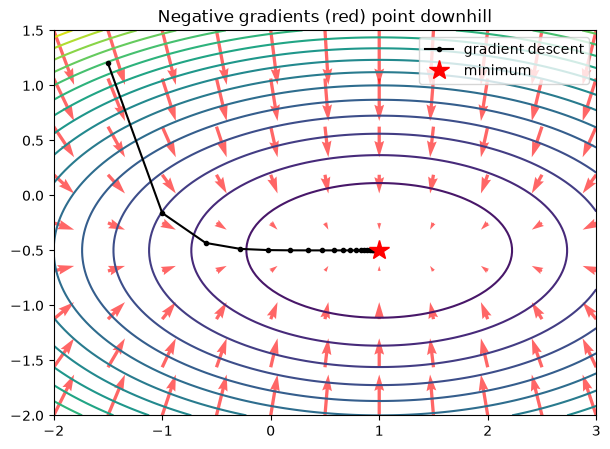

In [3]:
def loss(w1, w2):
    return (w1 - 1) ** 2 + 4 * (w2 + 0.5) ** 2

def grad(w1, w2):
    return np.array([2 * (w1 - 1), 8 * (w2 + 0.5)])

W1, W2 = np.meshgrid(np.linspace(-2, 3, 100), np.linspace(-2, 1.5, 100))
plt.figure(figsize=(7, 5))
plt.contour(W1, W2, loss(W1, W2), levels=20, cmap="viridis")
g1, g2 = np.meshgrid(np.linspace(-2, 3, 11), np.linspace(-2, 1.5, 9))
G = grad(g1, g2)
plt.quiver(g1, g2, -G[0], -G[1], color="r", alpha=0.6)
w = np.array([-1.5, 1.2]); path = [w.copy()]
for _ in range(25):
    w -= 0.1 * grad(*w); path.append(w.copy())
path = np.array(path)
plt.plot(path[:, 0], path[:, 1], "ko-", ms=3, label="gradient descent")
plt.plot(1, -0.5, "r*", ms=15, label="minimum"); plt.legend()
plt.title("Negative gradients (red) point downhill"); plt.show()

## **3. The Chain Rule**
If $y = f(g(x))$ then $\frac{dy}{dx} = f'(g(x))\cdot g'(x)$. A neural network is a long chain of functions; **backpropagation** applies the chain rule from the output back to every weight.

Example: logistic regression on one sample, $z = wx+b$, $p=\sigma(z)$, $L = -[y\log p + (1-y)\log(1-p)]$:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial p}\cdot\frac{\partial p}{\partial z}\cdot\frac{\partial z}{\partial w} = \frac{p-y}{p(1-p)}\cdot p(1-p)\cdot x = (p-y)\,x$$

In [4]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
def bce(w, b, x, y):
    p = sigmoid(w * x + b)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

w, b, x, y = 0.7, -0.2, 2.0, 1
p = sigmoid(w * x + b)
print(f"chain rule dL/dw = {(p - y) * x:.6f} | numerical = {numerical_derivative(lambda ww: bce(ww, b, x, y), w):.6f}")

chain rule dL/dw = -0.462950 | numerical = -0.462950


## **4. Derivatives We Will Meet Again and Again**

| Function | Formula | Derivative |
|---|---|---|
| Sigmoid | $\sigma(z)=\frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ |
| tanh | $\tanh z$ | $1-\tanh^2 z$ |
| ReLU | $\max(0,z)$ | $1$ if $z>0$ else $0$ |
| MSE | $\frac1n\sum(\hat y-y)^2$ | $\frac2n(\hat y - y)$ |
| Softmax + cross-entropy | $-\sum_k y_k\log\text{softmax}(z)_k$ | $\text{softmax}(z)-y$ |

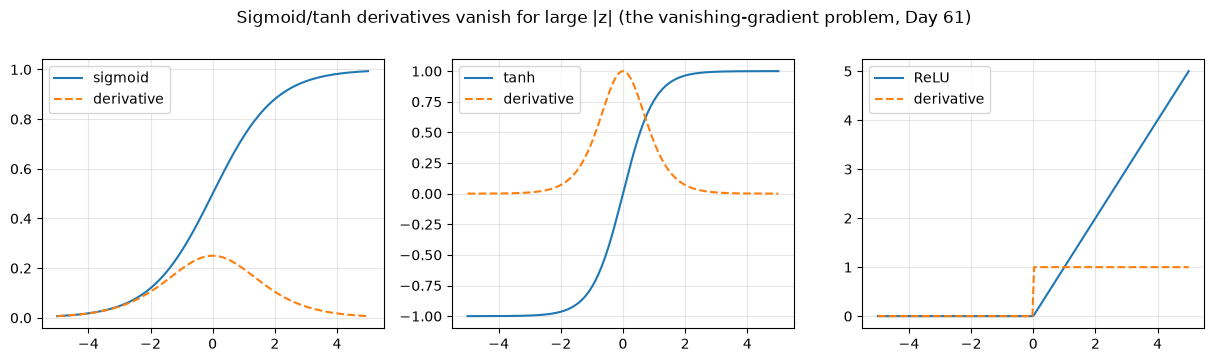

In [5]:
z = np.linspace(-5, 5, 200)
acts = {"sigmoid": (sigmoid(z), sigmoid(z) * (1 - sigmoid(z))),
        "tanh": (np.tanh(z), 1 - np.tanh(z) ** 2),
        "ReLU": (np.maximum(0, z), (z > 0).astype(float))}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, (fz, dz)) in zip(axes, acts.items()):
    ax.plot(z, fz, label=name); ax.plot(z, dz, "--", label="derivative"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Sigmoid/tanh derivatives vanish for large |z| (the vanishing-gradient problem, Day 61)", y=1.02); plt.show()

In [6]:
def softmax(z):
    e = np.exp(z - z.max())          # subtract max for numerical stability
    return e / e.sum()

zv = np.array([2.0, 1.0, -1.0]); yv = np.array([0, 1, 0])
ce = lambda zz: -np.sum(yv * np.log(softmax(zz)))
num_grad = np.array([numerical_derivative(lambda t: ce(np.where(np.arange(3) == i, t, zv)), zv[i]) for i in range(3)])
print("softmax - y   :", (softmax(zv) - yv).round(6))
print("numerical grad:", num_grad.round(6))

softmax - y   : [ 0.705385 -0.740504  0.035119]
numerical grad: [ 0.705385 -0.740504  0.035119]


## **5. Jacobian, Hessian and Convexity**
- **Jacobian**: matrix of first derivatives of a vector-valued function (used in backprop through layers).
- **Hessian** $H_{ij}=\frac{\partial^2 f}{\partial w_i\partial w_j}$: the curvature. If $H$ is positive semi-definite everywhere, $f$ is **convex**: any local minimum is the global minimum (linear/logistic regression, SVM). Neural network losses are **non-convex**.

In [7]:
H = np.array([[2, 0], [0, 8]])          # Hessian of loss(w1, w2) above (constant)
print("Hessian eigenvalues:", np.linalg.eigvalsh(H), "-> all positive -> convex")
print("Condition number:", np.linalg.cond(H), "-> elongated contours, GD zig-zags (see Day 13)")

Hessian eigenvalues: [2. 8.] -> all positive -> convex
Condition number: 4.0 -> elongated contours, GD zig-zags (see Day 13)


# **Part 2: Going Deeper - Build Our Own Autodiff Engine**

Frameworks like PyTorch record every operation in a **computational graph** and apply the chain rule backwards (**reverse-mode automatic differentiation**). Below is a complete scalar autodiff engine in ~40 lines (inspired by Karpathy's *micrograd*).

In [8]:
class Value:
    def __init__(self, data, parents=(), op=""):
        self.data, self.grad = float(data), 0.0
        self._parents, self._op, self._backward = parents, op, lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad; other.grad += out.grad
        out._backward = _backward; return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad; other.grad += self.data * out.grad
        out._backward = _backward; return out

    def __pow__(self, k):
        out = Value(self.data ** k, (self,), f"**{k}")
        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward; return out

    def exp(self):
        out = Value(np.exp(self.data), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward; return out

    def log(self):
        out = Value(np.log(self.data), (self,), "log")
        def _backward():
            self.grad += out.grad / self.data
        out._backward = _backward; return out

    __radd__ = __add__; __rmul__ = __mul__
    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return (-self) + other
    def __truediv__(self, other): return self * other ** -1
    def __rtruediv__(self, other): return Value(other) * self ** -1

    def backward(self):
        order, seen = [], set()
        def build(v):                                  # topological sort of the graph
            if v not in seen:
                seen.add(v); [build(p) for p in v._parents]; order.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(order):
            v._backward()

    def __repr__(self): return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

# The logistic-regression example, now differentiated automatically
w_, b_ = Value(0.7), Value(-0.2)
p_ = 1 / (1 + (-(w_ * x + b_)).exp())
L_ = -(y * p_.log() + (1 - y) * (1 - p_).log())
L_.backward()
print("loss:", L_)
print(f"autodiff dL/dw = {w_.grad:.6f} | chain rule by hand = {(p - y) * x:.6f}")
print(f"autodiff dL/db = {b_.grad:.6f} | by hand            = {(p - y):.6f}")

loss: Value(data=0.2633, grad=1.0000)
autodiff dL/dw = -0.462950 | chain rule by hand = -0.462950
autodiff dL/db = -0.231475 | by hand            = -0.231475


### Training a model with our autodiff engine
Fit $y = 2x - 1$ by gradient descent using only `Value` objects.

In [9]:
xs_d = rng.uniform(-1, 1, 30); ys_d = 2 * xs_d - 1 + rng.normal(0, 0.1, 30)
W, B = Value(0.0), Value(0.0)
for step in range(60):
    L = sum((W * xi + B - yi) ** 2 for xi, yi in zip(xs_d, ys_d)) / len(xs_d)
    W.grad = B.grad = 0.0
    L.backward()
    W.data -= 0.3 * W.grad; B.data -= 0.3 * B.grad
    if step % 15 == 0 or step == 59:
        print(f"step {step:2d}  loss {L.data:.4f}  w {W.data:.3f}  b {B.data:.3f}")

step  0  loss 2.5769  w 0.388  b -0.761
step 15  loss 0.0224  w 1.829  b -1.037
step 30  loss 0.0152  w 1.962  b -1.015
step 45  loss 0.0152  w 1.975  b -1.013
step 59  loss 0.0152  w 1.976  b -1.013


This is exactly what `loss.backward()` and `optimizer.step()` do in PyTorch (Day 59), just with tensors instead of scalars.

### Gradient checking
When we implement gradients by hand, always compare them with numerical gradients. The relative error should be < 1e-6.

In [10]:
def grad_check(f, grad_f, w, h=1e-6):
    num = np.array([(f(w + h * e) - f(w - h * e)) / (2 * h) for e in np.eye(len(w))])
    ana = grad_f(w)
    return np.linalg.norm(num - ana) / (np.linalg.norm(num) + np.linalg.norm(ana))

Xg = rng.normal(size=(50, 4)); yg = rng.normal(size=50)
mse = lambda w: np.mean((Xg @ w - yg) ** 2)
mse_grad = lambda w: 2 / len(yg) * Xg.T @ (Xg @ w - yg)
print("Relative error (correct gradient):", grad_check(mse, mse_grad, rng.normal(size=4)))
print("Relative error (buggy gradient)  :", grad_check(mse, lambda w: 1 / len(yg) * Xg.T @ (Xg @ w - yg), rng.normal(size=4)))

Relative error (correct gradient): 1.1610218916616589e-10
Relative error (buggy gradient)  : 0.33333333332115117


## **Practice Problems**
1. Find the derivative of $f(x)=\ln(1+e^x)$ (softplus) by hand. Verify numerically at x = 0.5.
2. Add a `tanh()` method to `Value` and check its gradient against $1-\tanh^2$.
3. Derive the gradient of the MSE loss for linear regression in matrix form and check it with `grad_check` (done above; explain each term).
4. *(Advanced)* Use the `Value` class to fit a logistic regression with 2 weights on a small dataset.

In [11]:
# Solution 1: softplus'(x) = sigmoid(x)
sp = lambda x: np.log1p(np.exp(x))
print(sigmoid(0.5), numerical_derivative(sp, 0.5))

# Solution 2
def _tanh(self):
    t = np.tanh(self.data); out = Value(t, (self,), "tanh")
    def _backward():
        self.grad += (1 - t ** 2) * out.grad
    out._backward = _backward; return out
Value.tanh = _tanh
v = Value(0.3); o = v.tanh(); o.backward(); print(v.grad, 1 - np.tanh(0.3) ** 2)

# Solution 4
Xl = rng.normal(size=(40, 2)); yl = (Xl[:, 0] - Xl[:, 1] > 0).astype(int)
w1, w2, b0 = Value(0.0), Value(0.0), Value(0.0)
for _ in range(50):
    L = Value(0.0)
    for (a1, a2), t in zip(Xl, yl):
        pp = 1 / (1 + (-(w1 * a1 + w2 * a2 + b0)).exp())
        L = L - (t * pp.log() + (1 - t) * (1 - pp).log())
    L = L / len(yl)
    for prm in (w1, w2, b0): prm.grad = 0.0
    L.backward()
    for prm in (w1, w2, b0): prm.data -= 1.0 * prm.grad
print(f"w1={w1.data:.2f}, w2={w2.data:.2f} (w1 ~ -w2 as expected), loss={L.data:.3f}")

0.6224593312018546 0.6224593311954241
0.9151369618266292 0.9151369618266292
w1=2.65, w2=-3.00 (w1 ~ -w2 as expected), loss=0.126


## **Key References**
- Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). Automatic differentiation in machine learning: a survey. *Journal of Machine Learning Research*, 18(153), 1-43.
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533-536.
- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Chapter 5. Cambridge University Press.